## Running kinGEMs Pipeline on $E. coli$ iML1515 Model

In [20]:

%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import cobra # type: ignore
import numpy as np # type: ignore
from datetime import datetime
import random
from cobra.io import write_sbml_model # type: ignore
import cobra as cb
from copy import deepcopy
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.metrics import r2_score

# Add parent directory to Python path
sys.path.append(os.path.abspath('..'))

# Import kinGEMs components
# import kinGEMs
from kinGEMs.dataset import load_model, convert_to_irreversible, prepare_model_data, retrieve_sequences, map_metabolites, merge_substrate_sequences, process_merged_data_with_folds, process_kcat_predictions, assign_kcats_to_model, format_kcats_like_gpr, annotate_model_with_kcat_and_gpr
from kinGEMs.modeling.optimize import run_optimization_with_dataframe, validate_enzyme_constraints
from kinGEMs.modeling.tuning import simulated_annealing, analyze_kcat_changes
from kinGEMs.modeling.fva import flux_variability_analysis, plot_flux_variability, plot_cumulative_fvi_distribution


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Set your GEM name here

In [8]:

# === Configuration ===
organism_strain_GEMname = "382_genome_cpd03198" # Update this
organism = "E coli" # Update this 
run_id = f"{organism_strain_GEMname}_{datetime.today().strftime('%Y%m%d')}_{random.randint(1000, 9999)}"

# Directories
data_dir = "../data"
biolog_dir = os.path.join(data_dir, "Biolog experiments")
raw_data_dir = os.path.join(data_dir, "raw")
interim_data_dir = os.path.join(data_dir, "interim")
interim_data_dir_spec = os.path.join(interim_data_dir, f"{organism_strain_GEMname}")
processed_data_dir = os.path.join(data_dir, "processed")
processed_data_dir_spec = os.path.join(processed_data_dir, f"{organism_strain_GEMname}")
CPIPred_data_dir = os.path.join(interim_data_dir, "CPI-Pred predictions")
results_dir = os.path.join(os.getcwd(), "results")
tuning_results_dir = os.path.join(results_dir, "tuning_results", run_id)
os.makedirs(tuning_results_dir, exist_ok=True)

# Input files
model_path = os.path.join(raw_data_dir, f"{organism_strain_GEMname}.xml") # Update this
predictions_csv_path = os.path.join(CPIPred_data_dir, f"X06A_kinGEMs_{organism_strain_GEMname}_predictions.csv")
metadata_path = os.path.join(biolog_dir, f"rxnXgenes_382_genome.csv") # Update this data\Biolog experiments\rxnXgenes_382_genome.csv
biolog_experiments_path = os.path.join(biolog_dir, f"FBA_results.xlsx")

# Output files
substrates_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_substrates.csv")
sequences_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_sequences.csv")
merged_data_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_merged_data.csv")
processed_data_output = os.path.join(processed_data_dir_spec, f"{organism_strain_GEMname}_processed_data.csv")

# Load your model 
model = cobra.io.read_sbml_model(model_path)

# Print the whole objective
print("Objective expression:", model.objective.expression)
print("Direction:", model.objective.direction)  # 'max' or 'min'

# List all reactions with a non‐zero coefficient
obj_rxns = {rxn.id: rxn.objective_coefficient
            for rxn in model.reactions
            if rxn.objective_coefficient != 0}

print("Objective reaction(s) and coefficient(s):")
for rxn_id, coeff in obj_rxns.items():
    print(f"  {rxn_id} → {coeff}")

obj_rxn_id = next(rxn.id for rxn in model.reactions if rxn.objective_coefficient != 0)
print("Primary objective reaction:", obj_rxn_id)

# Simulation parameters
biomass_reaction = obj_rxn_id # Update this
enzyme_upper_bound = 0.15


'382_genome' is not a valid SBML 'SId'.


Set parameter Username
Academic license - for non-commercial use only - expires 2026-02-25
Objective expression: 1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Direction: max
Objective reaction(s) and coefficient(s):
  EX_cpd11416_c0 → 1.0
Primary objective reaction: EX_cpd11416_c0


In [9]:
model.optimize()

,fluxes,reduced_costs
rxn00001_c0,0.000000,-2.627932e-02
rxn00003_c0,0.000000,1.751955e-02
rxn00006_c0,0.000000,0.000000e+00
rxn00007_c0,0.000000,-1.970949e-02
rxn00010_c0,0.000000,-2.627932e-02
...,...,...
rxn06046_c0,0.000000,-6.938894e-18
rxn09428_c0,0.051410,-1.387779e-17
rxn19870_c0,0.000000,0.000000e+00
rxn31225_c0,0.000000,-0.000000e+00


### Step 1: Preparing and processing model data

In [10]:

print("=== Step 1: Preparing model data ===")
irrev_model, substrate_df, sequences_df = prepare_model_data(
    model_path=model_path,
    substrates_output=substrates_output,
    sequences_output=sequences_output,
    organism=organism,
    metadata_dir=metadata_path
)


=== Step 1: Preparing model data ===


SBML errors in validation, check error log for details.
COBRA errors in validation, check error log for details.


'382_genome' is not a valid SBML 'SId'.


Loaded model with 3011 reactions and 2360 metabolites
Extracted 6321 substrate-reaction pairs


2025-07-08 12:18:18,432 - kinGEMs.dataset - INFO - There are 1742 substrates in the GEM.
2025-07-08 12:18:18,468 - kinGEMs.dataset - INFO - Mapping substrate: cpd00001_c0
2025-07-08 12:18:18,471 - kinGEMs.dataset - INFO - Found SMILES in ModelSEED for cpd00001: O
2025-07-08 12:18:18,471 - kinGEMs.dataset - INFO - Mapping substrate: cpd00012_c0
2025-07-08 12:18:18,473 - kinGEMs.dataset - INFO - Found SMILES in ModelSEED for cpd00012: O=P([O-])([O-])OP(=O)([O-])O
2025-07-08 12:18:18,474 - kinGEMs.dataset - INFO - Mapping substrate: cpd00011_c0
2025-07-08 12:18:18,476 - kinGEMs.dataset - INFO - Found SMILES in ModelSEED for cpd00011: O=C=O
2025-07-08 12:18:18,477 - kinGEMs.dataset - INFO - Mapping substrate: cpd00668_c0
2025-07-08 12:18:18,479 - kinGEMs.dataset - INFO - Found SMILES in ModelSEED for cpd00668: CC(=O)C(C)(O)C(=O)[O-]
2025-07-08 12:18:18,479 - kinGEMs.dataset - INFO - Mapping substrate: cpd00025_c0
2025-07-08 12:18:18,482 - kinGEMs.dataset - INFO - Found SMILES in ModelSEED 

...

UniProt, raw_q UniRef50_A0A0A7PQQ3


2025-07-08 12:31:45,681 - root - WARNING - UniRef miss for NODE_1_100478_98322 (UniRef50_A0A0A7PQQ3)
2025-07-08 12:31:46,122 - root - WARNING - Gene_exact miss for NODE_1_100478_98322


SP, TR: acc, reviewed Q9L7R5 True


2025-07-08 12:31:46,563 - root - WARNING - UniProtKB miss for NODE_1_187234_185876 (sp|Q9L7R5|YIHP_SALTY|2.A.2.3.9)
2025-07-08 12:31:47,009 - root - WARNING - Gene_exact miss for NODE_1_187234_185876


UniProt, raw_q UniRef90_Q8RSY9
Retrieved 675 protein sequences


### Step 2: Merging substrate and sequence data

In [11]:

print("=== Step 2: Merging substrate and sequence data ===")

# substrate_df = pd.read_csv(substrates_output)
# sequences_df = pd.read_csv(sequences_output)
# model = load_model(model_path)

merged_data = merge_substrate_sequences(
    substrate_df=substrate_df,
    sequences_df=sequences_df,
    model=irrev_model,
    output_path=merged_data_output
)


=== Step 2: Merging substrate and sequence data ===


### Step 3: Processing CPI-Pred kcat values

In [12]:

print("=== Step 3: Processing CPI-Pred kcat values & annotating model ===")
processed_data = process_kcat_predictions(
    merged_df=merged_data,
    predictions_csv_path=predictions_csv_path,
    output_path=processed_data_output
)

irrev_model = annotate_model_with_kcat_and_gpr(
    model=irrev_model,
    df=processed_data
)


=== Step 3: Processing CPI-Pred kcat values & annotating model ===


## Step 4: Optimization (FBA Sanity Check + kinGEMs)

make sure code below works first

In [13]:
from cobra.util.array import create_stoichiometric_matrix
import pyomo.environ as pyo
from pyomo.environ import *  # noqa: F403
from pyomo.opt import SolverFactory, SolverStatus, TerminationCondition

# 1) Load your COBRApy model
model = irrev_model
# Or if you have a JSON:
# model = cobra.io.load_json_model("path/to/your_model.json")

# 2) Extract S, bounds, and objective coefficients
#    S will be shape (m metabolites × n reactions)
S = create_stoichiometric_matrix(model)  

metabolites = list(model.metabolites)
reactions   = list(model.reactions)
m, n = S.shape

lb = np.array([rxn.lower_bound for rxn in reactions])
ub = np.array([rxn.upper_bound for rxn in reactions])
c  = np.array([rxn.objective_coefficient for rxn in reactions])

print("objective_coefficient: ", [rxn.objective_coefficient for rxn in reactions])
print("same but with our option: ", {r.id: (1.0 if r.id == biomass_reaction else 0.0) for r in model.reactions})
print("original option:", {r.id: r.objective_coefficient for r in model.reactions})

# 3) Build the Pyomo model
pyomo_model = ConcreteModel()
pyomo_model.I = Set(initialize=range(m))  # metabolite indices
pyomo_model.J = Set(initialize=range(n))  # reaction indices

# flux variables v[j] with the same bounds
def v_bounds(mod, j):
    return (float(lb[j]), float(ub[j]))
pyomo_model.v = Var(pyomo_model.J, domain=Reals, bounds=v_bounds)

# mass‐balance constraints: for each metabolite i, sum_j S[i,j]*v[j] == 0
def mass_balance_rule(mod, i):
    return sum(S[i, j] * mod.v[j] for j in mod.J) == 0
pyomo_model.mass_balance = Constraint(pyomo_model.I, rule=mass_balance_rule)

# objective: maximize cᵀ v
pyomo_model.obj = Objective(
    expr = sum(c[j] * pyomo_model.v[j] for j in pyomo_model.J),
    sense = maximize
)

# 4) Solve it with GLPK (or another LP solver you've installed)
solver = SolverFactory('glpk')
result = solver.solve(pyomo_model, tee=False)

# 5) Extract Pyomo solution
pyomo_fluxes = np.array([value(pyomo_model.v[j]) for j in range(n)])
pyomo_obj     = value(pyomo_model.obj)

# 6) Solve with COBRApy’s built-in optimizer for comparison
cobra_solution = model.optimize()
cobra_fluxes   = np.array([cobra_solution.fluxes[rxn.id] for rxn in reactions])
cobra_obj      = cobra_solution.objective_value

# 7) Verify they match
print(f" COBRA optimize() objective: {cobra_obj:.6g}")
print(f"   Pyomo objective:        {pyomo_obj:.6g}")
print(" Max |flux_pyomo – flux_cobra| =", np.max(np.abs(pyomo_fluxes - cobra_fluxes)))


objective_coefficient:  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 

In [14]:
print("=== Step 4: Running optimization with kcat constraints ===")
(solution_value, df_FBA, gene_sequences_dict, _)=run_optimization_with_dataframe(
    model=irrev_model, 
    processed_df=processed_data, 
    objective_reaction=biomass_reaction, 
    enzyme_upper_bound=enzyme_upper_bound, 
    enzyme_ratio=True, 
    maximization=True, 
    multi_enzyme_off=False, 
    isoenzymes_off=False, 
    promiscuous_off=False, 
    complexes_off=False,
    output_dir=None, 
    save_results=False,
    print_reaction_conditions=True)

print("Biomass value: ", solution_value)

=== Step 4: Running optimization with kcat constraints ===
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Biomass value:  0.36330231503196436


### Step 5: Simulated Annealing

=== Step 5: Running simulated annealing ===
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607

--- Iteration 1 ---
Current biomass = 3.633023e-01
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Proposed biomass = 4.461297e-01

--- Iteration 2 ---
Current biomass = 4.461297e-01
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Proposed biomass = 5.159180e-01

--- Iteration 3 ---
Current biomass = 5.159180e-01
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Proposed biomass = 5.537617e-01

--- Iteration 4 ---
Current biomass = 5.537617e-01
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Proposed biomass = 5.798498e-01

--- Iteration 5 ---
Current biomass = 5.798498e-01
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Proposed biomass = 5.900042e-01

--- Iteration 6 ---
Current biomass = 5.900042e-01
Mode

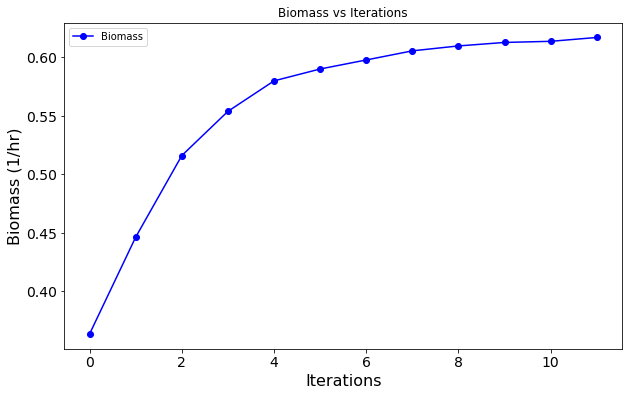

In [15]:

print("=== Step 5: Running simulated annealing ===")
temperature = 1.0
cooling_rate = 0.95
min_temperature = 0.01
max_iterations = 100
max_unchanged_iterations = 4
change_threshold = 0.009
biomass_goal = 1

kcat_dict, top_targets, df_new, iterations, biomasses, df_FBA = simulated_annealing(
    model=irrev_model,
    processed_data=processed_data,
    biomass_reaction=biomass_reaction,
    objective_value=biomass_goal,
    gene_sequences_dict=gene_sequences_dict,      # ← new
    output_dir=tuning_results_dir,
    enzyme_fraction=enzyme_upper_bound,
    temperature=temperature,
    cooling_rate=cooling_rate,
    min_temperature=min_temperature,
    max_iterations=max_iterations,
    max_unchanged_iterations=max_unchanged_iterations,
    change_threshold=change_threshold
)

print(f"Final biomass: {biomasses[-1]:.4f}")
print(f"Improvement: {(biomasses[-1] - biomasses[0]) / biomasses[0] * 100:.1f}%")
print("Top 10 enzymes by mass contribution:")
print(top_targets[['Reactions','Single_gene','enzyme_mass']])


### Step 6: Experimental Comparative Analysis

In [ ]:
# Enzyme-constrained FBA across C-sources with annealed kcat values
import pandas as pd
import matplotlib.pyplot as plt
from cobra import Model
from kinGEMs.modeling.optimize import run_optimization_with_dataframe
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.metrics import r2_score

# 1) Load and clean experimental data ("Ecoli" sheet)
exp_df = pd.read_excel(
    biolog_experiments_path,
    sheet_name="Ecoli",
    engine="openpyxl",
)
# 2) Use annealed kcat dataframe returned by simulated annealing
processed_data = df_new.copy()

# 3) Blocked compounds
blocked_cpds = [
    "cpd00224","cpd00122","cpd00609","cpd00108","cpd00794","cpd00138",
    "cpd00588","cpd00751","cpd00164","cpd00222","cpd00154","cpd00314",
    "cpd00105","cpd00396","cpd00082","cpd00027","cpd00179","cpd03198",
    "cpd00184","cpd00208","cpd00249","cpd01262","cpd00182","cpd00246",
    "cpd00054","cpd00020","cpd00280","cpd00832","cpd00232","cpd00276"
]

# 4) Simulation helper
from copy import deepcopy

def simulate_enzyme_rate(
    base_model: Model,
    processed_df,
    biomass_reaction: str,
    gene_sequences_dict: dict,
    cpd_id: str,
    uptake_rate: float = 10.0
) -> float:
    saved = {}
    for c in blocked_cpds + [cpd_id]:
        ex = f"EX_{c}_e0"
        if ex in base_model.reactions:
            saved[ex] = base_model.reactions.get_by_id(ex).lower_bound
    for c in blocked_cpds:
        if c == cpd_id: continue
        ex = f"EX_{c}_e0"
        if ex in base_model.reactions:
            base_model.reactions.get_by_id(ex).lower_bound = 0.0
    target_ex = f"EX_{cpd_id}_e0"
    if target_ex not in base_model.reactions:
        raise KeyError(f"Exchange {target_ex} not found")
    base_model.reactions.get_by_id(target_ex).lower_bound = -abs(uptake_rate)
    sol_val, _, _, _ = run_optimization_with_dataframe(
        model=base_model,
        processed_df=processed_df,
        objective_reaction=biomass_reaction,
        enzyme_upper_bound=enzyme_upper_bound,
        enzyme_ratio=True,
        maximization=True,
        multi_enzyme_off=False,
        isoenzymes_off=False,
        promiscuous_off=False,
        complexes_off=False,
        output_dir=None,
        save_results=False,
        print_reaction_conditions=False
    )
    for ex, lb in saved.items():
        base_model.reactions.get_by_id(ex).lower_bound = lb
    return sol_val

# 5) Baseline on glucose
print("=== Baseline: glucose ===")
glc = "cpd00027"
glc_rate = simulate_enzyme_rate(
    base_model=irrev_model,
    processed_df=processed_data,
    biomass_reaction=biomass_reaction,
    gene_sequences_dict=gene_sequences_dict,
    cpd_id=glc,
    uptake_rate=10.0
)
print(f"Enzyme-constrained glucose growth = {glc_rate:.4f}\n")

# 6) Loop through substrates, collect lists of experimental vs normalized model values
cpd_list, exp_list, norm_model_list = [], [], []
for row in exp_df.itertuples(index=False):
    cpd, exp_val = row.cpd, row.exp_value
    print(f"=== Testing substrate: {cpd} ===")
    try:
        raw_rate = simulate_enzyme_rate(
            base_model=irrev_model,
            processed_df=processed_data,
            biomass_reaction=biomass_reaction,
            gene_sequences_dict=gene_sequences_dict,
            cpd_id=cpd,
            uptake_rate=10.0
        )
        norm_rate = raw_rate / glc_rate
        print(f"Raw predicted rate: {raw_rate:.4f}")
        print(f"Normalized predicted rate: {norm_rate:.4f}")
    except Exception as e:
        raw_rate, norm_rate = None, None
        print(f"⚠️ Warning {cpd}: {e}")
    print(f"Experimental value: {exp_val:.4f}\n")

    cpd_list.append(cpd)
    exp_list.append(exp_val)
    norm_model_list.append(norm_rate)

# 7) Display summary lists
print("=== Summary Lists ===")
for cpd, exp_val, norm_val in zip(cpd_list, exp_list, norm_model_list):
    print(f"{cpd}: experimental={exp_val:.4f}, normalized_model={norm_val:.4f}")
print()

# 8) Correlation on normalized values
valid = [(e,m) for e,m in zip(exp_list, norm_model_list) if m is not None]
if len(valid) >= 2:
    exp_vals, mod_vals = zip(*valid)
    pearson_r, _ = pearsonr(exp_vals, mod_vals)
    spearman_rho, _ = spearmanr(exp_vals, mod_vals)
    kendall_tau, _ = kendalltau(exp_vals, mod_vals)
    r2 = r2_score(exp_vals, mod_vals)
    print("=== Correlation Statistics ===")
    print(f"Pearson r: {pearson_r:.3f}")
    print(f"Spearman rho: {spearman_rho:.3f}")
    print(f"Kendall tau: {kendall_tau:.3f}")
    print(f"R²: {r2:.3f}\n")
else:
    print("Not enough valid data points for correlation (need at least 2).\n")

# 9) Plot normalized rates vs experimental
plt.figure(figsize=(6,4))
plt.scatter(exp_list, norm_model_list, s=60)
plt.xlabel('Experimental value')
plt.ylabel('Model predicted rate (normalized to glucose)')
plt.title('Normalized Enzyme-constrained FBA vs. Experimental')
plt.grid(True)
plt.tight_layout()
plt.show()


=== Baseline: glucose ===
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Enzyme-constrained glucose growth = 0.6175

=== Testing substrate: cpd00224 ===
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Raw predicted rate: 0.4825
Normalized predicted rate: 0.7813
Experimental value: 0.3446

=== Testing substrate: cpd00122 ===
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Raw predicted rate: 0.6382
Normalized predicted rate: 1.0336
Experimental value: 20.9701

=== Testing substrate: cpd00609 ===
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Raw predicted rate: 0.3170
Normalized predicted rate: 0.5134
Experimental value: 0.7083

=== Testing substrate: cpd00108 ===
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Raw predicted rate: 0.5743
Normalized predicted rate: 0.9300
Experimental value: 0.3479

=== Testing substrate: cpd007

=== Filtered Summary Lists ===
cpd00224: experimental=0.3446, normalized_model=0.7694
cpd00609: experimental=0.7083, normalized_model=0.3509
cpd00108: experimental=0.3479, normalized_model=0.6146
cpd00794: experimental=0.3710, normalized_model=1.0074
cpd00138: experimental=0.6840, normalized_model=0.8350
cpd00588: experimental=0.4899, normalized_model=0.6698
cpd00751: experimental=0.5083, normalized_model=0.4418
cpd00222: experimental=0.6303, normalized_model=0.6661
cpd00314: experimental=0.7665, normalized_model=0.8098
cpd00105: experimental=1.0346, normalized_model=1.0399
cpd00396: experimental=0.8676, normalized_model=0.5204
cpd00082: experimental=0.7009, normalized_model=1.0473
cpd00179: experimental=0.4433, normalized_model=0.6274
cpd03198: experimental=0.1693, normalized_model=0.8161
cpd00184: experimental=0.4523, normalized_model=0.3211
cpd00208: experimental=0.7535, normalized_model=0.7346
cpd00249: experimental=0.4132, normalized_model=1.0851
cpd01262: experimental=0.5581, nor

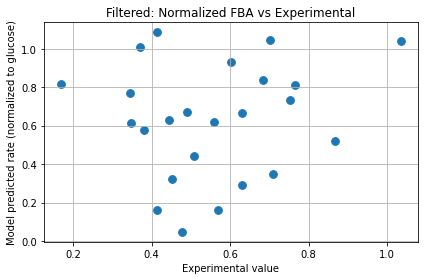

In [ ]:
# Running same analysis only on data points where outliers removed: 
filtered = [
    (cpd, e, m)
    for cpd, e, m in zip(cpd_list, exp_list, norm_model_list)
    if e <= 5 and not (e == 1.0 and m == 1.0)
]
if not filtered:
    raise RuntimeError("No datapoints remain after filtering.")

cpds_f, exps_f, norms_f = zip(*filtered)

# 7b) Display filtered summary
print("=== Filtered Summary Lists ===")
for cpd, exp_val, norm_val in filtered:
    print(f"{cpd}: experimental={exp_val:.4f}, normalized_model={norm_val:.4f}")
print()

# 8) Recompute correlations on filtered data
if len(exps_f) >= 2:
    pearson_r, _    = pearsonr(exps_f, norms_f)
    spearman_rho, _ = spearmanr(exps_f, norms_f)
    kendall_tau, _  = kendalltau(exps_f, norms_f)
    r2             = r2_score(exps_f, norms_f)

    print("=== Filtered Correlation Statistics ===")
    print(f"Pearson r:   {pearson_r:.3f}")
    print(f"Spearman ρ:  {spearman_rho:.3f}")
    print(f"Kendall τ:   {kendall_tau:.3f}")
    print(f"R²:          {r2:.3f}\n")
else:
    print("Not enough valid data points for correlation (need ≥2).\n")

# 9) Plot filtered normalized vs experimental
plt.figure(figsize=(6,4))
plt.scatter(exps_f, norms_f, s=60)
plt.xlabel('Experimental value')
plt.ylabel('Model predicted rate (normalized to glucose)')
plt.title('Filtered: Normalized FBA vs Experimental')
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
# Classification analysis
# after loading exp_df, which now has both 'exp_value' and 'exp_value_true':
exp_true_list = exp_df['exp_value_true'].astype(float).tolist()

# make sure exp_df has exactly the substrates you want to test
cpd_list = exp_df['cpd'].tolist()

# now build model_list of raw rates
model_list = []
for cpd in cpd_list:
    try:
        raw_rate = simulate_enzyme_rate(
            base_model=irrev_model,
            processed_df=processed_data,
            biomass_reaction=biomass_reaction,
            gene_sequences_dict=gene_sequences_dict,
            cpd_id=cpd,
            uptake_rate=10.0
        )
    except Exception as e:
        raw_rate = None
        print(f"Warning: could not predict for {cpd}: {e}")
    model_list.append(raw_rate)



from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

threshold = 0.005

# y_true: 1 if exp_value_true > threshold, else 0
y_true = [1 if e > threshold else 0 for e in exp_true_list]

# y_pred: 1 if raw model rate > threshold, else 0
# assume model_list holds your raw (not normalized) rates or None
y_pred = [1 if (m is not None and m > threshold) else 0 for m in model_list]

# for ROC AUC we’ll use the continuous raw predictions as scores (treat None→0)
scores = [m if m is not None else 0 for m in model_list]

print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))
print("\nClassification report:")
print(classification_report(
    y_true, y_pred,
    target_names=["no growth","growth"]
))

auc = roc_auc_score(y_true, scores)
fpr, tpr, _ = roc_curve(y_true, scores)

print(f"ROC AUC: {auc:.3f}")

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Growth vs No-Growth")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()



Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607
Model objective: Maximize
1.0*EX_cpd11416_c0 - 1.0*EX_cpd11416_c0_reverse_67607


KeyboardInterrupt: 

### Step 7: Save Final Model

In [ ]:
# Define output path for final GEM
model_output_dir = os.path.join("models")
os.makedirs(model_output_dir, exist_ok=True)
model_output_path = os.path.join(model_output_dir, f"{run_id}.xml")

# After simulated annealing
model_with_kcats = assign_kcats_to_model(irrev_model, df_new)

# Preview:
format_kcats_like_gpr(model_with_kcats.reactions.get_by_id("PGI"))


# Save the final irreversible model
write_sbml_model(model_with_kcats, model_output_path)

print(f"Final GEM saved to: {model_output_path}")